In [ ]:
#| default_exp clustering_analysis

# Libraries

In [ ]:
from numba import float64, int64,  njit, prange

import numpy as np
import matplotlib.pyplot as plt
from typing import Union
from tqdm.auto import tqdm

import os, socket

# Radial distribution function

In [ ]:
"""
Pair correlation function g(r) and related spatial statistics
for 2D foraging simulations with small N.

Main function: compute_gr()
Bonus:         clark_evans_index()  (scalar aggregation metric)
"""




def compute_gr(
    positions_list: list,
    L: float,
    dr: float = 0.5,
    r_max: float = None,
    periodic: bool = True,
) -> tuple:
    """
    Compute the radial distribution function g(r) for a 2D square box,
    accumulated over many frames (time steps and/or episodes).

    g(r) = 1 means random (ideal gas). g(r) > 1 at small r means aggregation.

    Parameters
    ----------
    positions_list : list of np.ndarray, shape (N, 2)
        One array per frame (time step or episode snapshot).
        N may vary between frames if agents enter/leave, but is
        typically fixed at N_a.
    L : float
        Side length of the square box.
    dr : float
        Bin width for r (same units as positions and L).
    r_max : float or None
        Maximum r to compute. Defaults to L/2, which is the safe
        limit for periodic boundary conditions to avoid shells
        that wrap around and double-count pairs.
    periodic : bool
        If True  -> periodic boundary conditions (torus), standard for
                    physics simulations.
        If False -> hard-wall box. A simple edge correction is applied
                    (fraction of the shell circle that falls inside the box),
                    which works well for r << L but is approximate near r_max.

    Returns
    -------
    r_centers : np.ndarray, shape (n_bins,)
        Bin centre positions.
    gr : np.ndarray, shape (n_bins,)
        g(r) values, normalised so that g(r) -> 1 for large r.
    counts : np.ndarray, shape (n_bins,)
        Raw pair counts per bin (useful for diagnosing empty bins at large r).
    """
    if r_max is None:
        r_max = L / 2.0

    n_bins = int(r_max / dr)
    r_edges = np.linspace(0, r_max, n_bins + 1)
    r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])

    hist_accum = np.zeros(n_bins, dtype=np.float64)
    # Track per-frame N and correction factor separately
    norm_accum = np.zeros(n_bins, dtype=np.float64)

    n_frames = 0

    for positions in positions_list:
        positions = np.asarray(positions, dtype=float)
        N = len(positions)
        if N < 2:
            continue
        n_frames += 1

        # ----------------------------------------------------------------
        # Pairwise distances (vectorised, fine for N=50)
        # ----------------------------------------------------------------
        diff = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]  # (N,N,2)

        if periodic:
            # Minimum image convention
            diff -= L * np.round(diff / L)
        # else: raw Cartesian differences (box assumed to be [0, L] x [0, L])

        r_matrix = np.sqrt((diff ** 2).sum(axis=-1))  # (N, N)

        # Only upper triangle (i < j) to count each pair once
        i_idx, j_idx = np.triu_indices(N, k=1)
        r_pairs = r_matrix[i_idx, j_idx]

        # Histogram of pair distances for this frame
        h, _ = np.histogram(r_pairs, bins=r_edges)
        hist_accum += h

        # ----------------------------------------------------------------
        # Expected counts for an ideal gas (normalisation denominator)
        # ----------------------------------------------------------------
        area = L ** 2
        rho = N / area
        n_pairs = N * (N - 1) / 2  # unordered pairs

        if periodic:
            # Shell is always a full annulus
            shell_areas = 2 * np.pi * r_centers * dr
            expected = n_pairs * shell_areas / area
        else:
            # Edge correction: for each shell, estimate the fraction of the
            # annulus that lies inside the [0,L]x[0,L] box.
            # This uses the mean-centre approximation (exact for a random
            # uniform centre averaged over the box).
            frac = _edge_correction(r_centers, dr, L)
            shell_areas = 2 * np.pi * r_centers * dr
            expected = n_pairs * shell_areas * frac / area

        norm_accum += expected

    if n_frames == 0:
        raise ValueError("No valid frames found (need at least 2 agents per frame).")

    # g(r) = observed / expected, both accumulated over all frames
    # Avoid division by zero for bins with no expected counts
    with np.errstate(invalid="ignore", divide="ignore"):
        gr = np.where(norm_accum > 0, hist_accum / norm_accum, 0.0)

    return r_centers, gr, hist_accum


def _edge_correction(r_centers: np.ndarray, dr: float, L: float) -> np.ndarray:
    """
    Approximate fraction of an annulus at radius r that lies inside a
    square box [0,L]x[0,L], averaged over all possible centre positions.
    Used for hard-wall (non-periodic) correction.

    This is an approximation valid when r < L. For r -> L/sqrt(2) corners
    start being clipped and accuracy degrades, so keep r_max < L/2.
    """
    r = r_centers
    frac = np.ones_like(r)

    # Fraction of circumference inside box (Ripley's edge correction, 2D square)
    # Each side clips the circle when r > distance from centre to that side.
    # For a random centre uniform in [0,L]^2, the average clipped fraction is:
    #   f(r) ≈ 1 - (2r / pi*L)   for r <= L/2   (linear approximation)
    # A more accurate closed-form (Haase 1995) for a square:
    mask = r < L / 2
    frac[mask] = 1.0 - (2 * r[mask]) / (np.pi * L)
    # For r > L/2 corners contribute; use a simple bounding estimate
    frac[~mask] = np.clip(1.0 - (2 * r[~mask]) / (np.pi * L), 0.05, 1.0)

    return frac


# ---------------------------------------------------------------------------
# Bonus: Clark and Evans aggregation index (scalar, small-N friendly)
# ---------------------------------------------------------------------------

def clark_evans_index(
    positions_list: list, L: float, periodic: bool = True
) -> tuple:
    """
    Compute the Clark and Evans (1954) aggregation index R, a scalar
    summary of spatial clustering averaged over frames.

        R = mean_nn_distance / expected_nn_distance

    R < 1  -> clustered
    R = 1  -> random (Poisson)
    R > 1  -> dispersed / regular

    Expected nearest-neighbour distance for a 2D Poisson process:
        E[d_nn] = 1 / (2 * sqrt(rho))

    Parameters
    ----------
    positions_list : list of np.ndarray, shape (N, 2)
    L : float
    periodic : bool

    Returns
    -------
    R : float
        Mean Clark-Evans index across frames.
    R_per_frame : np.ndarray
        Index computed for each individual frame.
    """
    R_vals = []
    area = L ** 2

    for positions in positions_list:
        positions = np.asarray(positions, dtype=float)
        N = len(positions)
        if N < 2:
            continue

        diff = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]

        if periodic:
            diff -= L * np.round(diff / L)

        r_matrix = np.sqrt((diff ** 2).sum(axis=-1))
        np.fill_diagonal(r_matrix, np.inf)  # exclude self

        nn_distances = r_matrix.min(axis=1)  # nearest neighbour for each agent
        mean_nn = nn_distances.mean()

        rho = N / area
        expected_nn = 1.0 / (2.0 * np.sqrt(rho))

        R_vals.append(mean_nn / expected_nn)

    R_per_frame = np.array(R_vals)
    return R_per_frame.mean(), R_per_frame


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_gr(
    results: dict,
    title: str = "Radial distribution function g(r)",
    figsize: tuple = (7, 4),
    ax=None,
):
    """
    Plot one or more g(r) curves on the same axes.

    Parameters
    ----------
    results : dict
        Keys are labels (str), values are (r_centers, gr) tuples as returned
        by compute_gr().  Example:
            {
                "social (cooperative)": (r_social, gr_social),
                "blind baseline":       (r_base,   gr_base),
            }
    title : str
    figsize : tuple
    ax : matplotlib Axes or None

    Returns
    -------
    fig, ax
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    for label, (r, gr) in results.items():
        ax.plot(r, gr, label=label, linewidth=1.8)

    ax.axhline(1.0, color="black", linestyle="--", linewidth=0.9,
               label="ideal gas (g=1)")
    ax.set_xlabel("r")
    ax.set_ylabel("g(r)")
    ax.set_title(title)
    ax.legend(framealpha=0.7)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    return fig, ax


# ---------------------------------------------------------------------------
# Usage example
# ---------------------------------------------------------------------------


In [ ]:



# ------------------------------------------------------------------
# Replace this block with your actual simulation output.
# positions_list should be a flat list of (N, 2) arrays,
# one per recorded time step, across all episodes you want to average.
#
# Example: if you run 10 episodes of 5000 steps and record every 10th
# step, you pass a list of 10 * 500 = 5000 arrays, each shape (50, 2).
# ------------------------------------------------------------------

# rng = np.random.default_rng(42)
# L = 50.0
# N = 50

# # Simulate "clustered" positions (agents near a few random centres)
# def make_clustered(n_agents, L, n_clusters=5, spread=2.0):
#     centres = rng.uniform(0, L, size=(n_clusters, 2))
#     assigned = rng.integers(0, n_clusters, size=n_agents)
#     pos = centres[assigned] + rng.normal(0, spread, size=(n_agents, 2))
#     pos = pos % L  # wrap into box (PBC)
#     return pos

# # Build two position lists: one clustered, one uniform
# frames_clustered = [make_clustered(N, L) for _ in range(2000)]
# frames_uniform   = [rng.uniform(0, L, size=(N, 2)) for _ in range(2000)]

# # Compute g(r)
# r_c, gr_c, _ = compute_gr(frames_clustered, L=L, dr=0.5)
# r_u, gr_u, _ = compute_gr(frames_uniform,   L=L, dr=0.5)

# # Clark-Evans index
# R_c, _ = clark_evans_index(frames_clustered, L=L)
# R_u, _ = clark_evans_index(frames_uniform,   L=L)
# print(f"Clark-Evans R (clustered): {R_c:.3f}  (< 1 means clustered)")
# print(f"Clark-Evans R (uniform):   {R_u:.3f}  (≈ 1 expected)")

# # Plot
# fig, ax = plot_gr(
#     results={
#         "clustered (example)": (r_c, gr_c),
#         "uniform   (example)": (r_u, gr_u),
#     },
#     title="g(r) comparison",
# )


# No-learning dynamics

In [ ]:
#| export
@njit
def simul_loop_collective(episodes, time_ep, env, agents, max_counter, visual_activated = False, upd_pos_method = 'RND'):
    """
    EXP 5: Target-finding reward with 3D state = [counter, any_agent_in_cone, rewarded_agent_in_cone].

    Uses Foragers_efficient with lazy G updates.
    state_space should be np.array([max_counter, 2, 2]).
    """
    save_rewards = np.zeros((agents.num_agents, episodes))
    agents_rewarded = np.zeros(agents.num_agents, dtype=np.bool_)
    positions = np.zeros((episodes,time_ep, env.num_agents, 2))

    for ep in range(episodes):
        env.init_env()
        agents.agent_states = np.zeros_like(agents.agent_states)
        agents.reset_g()
        
        # Debugging
        # positions = np.zeros((time_ep, env.num_agents, 2))

        for t in range(time_ep):
            agents.increment_counters()

            # --- Build observations ---
            # 1) Counter (clipped)
            counters = np.minimum(agents.get_state().copy(), np.int64(max_counter - 1))

            # 2) Cone features
            if visual_activated:
                _, agents_spot = env.agents_in_cone()
                # agents_spot is (num_agents, num_agents) with 1 if j is in i's cone

            # any_agent_in_cone: 1 if row sum > 0
            any_in_cone = np.zeros(agents.num_agents, dtype=np.float64)
            if visual_activated:
                for i in range(agents.num_agents):
                    if agents_spot[i].sum() > 0:
                        any_in_cone[i] = 1.0

            # rewarded_agent_in_cone: 1 if any agent with rewarded_agents==1 is in cone
            rewarded_in_cone = np.zeros(agents.num_agents, dtype=np.float64)
            if visual_activated: 
                for i in range(agents.num_agents):
                    for j in range(agents.num_agents):
                        if agents_spot[i, j] == 1 and env.rewarded_agents[j] == 1:
                            rewarded_in_cone[i] = 1.0
                            break

            # observations shape: (num_agents, 3)
            observations = np.empty((agents.num_agents, 3), dtype=np.float64)
            observations[:, 0] = counters.astype(np.float64)
            observations[:, 1] = any_in_cone
            observations[:, 2] = rewarded_in_cone

            actions = agents.deliberate(observations)

            # Post-reward step: force turn + reset counter BEFORE act
            actions[agents_rewarded] = 1
            agents.agent_states[agents_rewarded] = 0

            agents.act(actions)

            # Environment step
            if upd_pos_method == 'RND':
                env.update_pos(actions == 1)
            elif upd_pos_method == 'LR':
                env.update_pos(actions)                
            env.check_bc()
            env.update_target_state()
            env.update_rewarded_agents()

            positions[ep, t] = env.positions

            rewards = env.check_encounter()
            rewards[agents_rewarded] = 0  # suppress double reward

            save_rewards[:, ep] += rewards

            agents_rewarded = rewards == 1


    return save_rewards, positions

In [ ]:
#| eval: false
# from rl_opts.rl_framework.numba.agents import Foragers_efficient
# from rl_opts.rl_framework.numba.environments import CollectiveEnv
# import numpy as np



# num_agents = 5
# state_space = np.array([50, 2, 2])
# num_actions = 2
# # Previous h_mat
# h0 = np.zeros((num_agents, num_actions, np.prod(state_space)))


# agents = Foragers_efficient(num_agents, num_actions, state_space, h_0=h0, initial_h_0=True)

# env = CollectiveEnv(num_agents)

# episodes = 200; time_ep = 10; max_counter = state_space[0]
# rews, positions = simul_loop_collective(episodes, time_ep, env, agents, max_counter, visual_activated = True, upd_pos_method = 'RND')

In [ ]:
#| export
from rl_opts.rl_framework.numba.environments import CollectiveEnv
from rl_opts.rl_framework.numba.agents import Foragers_efficient

@njit(parallel=True)
def run_simul_collective(episodes, time_ep, runs,
             # Environment props
             Nt=100,
             L=100,
             r=0.5,
             tau=5,
             tau_reward=1,
             num_agents=10,
             agent_step=1,
             visual_range=2.0,
             visual_angle=np.pi / 2,
             shared_depletion=True,
             visual_activated = True,
             # Agent props
             num_actions=2,
             state_space=np.array([50, 2, 2]),
             gamma_damping=0.0,
             eta_glow_damping=0.0,
             initial_h_0=False,
             h_0=np.zeros((1, 2, 200)),
             g_update='s',
             policy_type='standard',
             beta_softmax=3,
             max_no_H_update=int(1e3),
             upd_pos_method = 'RND', # Method to update position. 'RND' for random angle turns, 'LR' for left/right turns.
             turn_angle = np.pi/4 # Angle for left/right turns if upd_pos_method is 'LR'.
             ):
    """
    Parallel launcher for collective training, where visual features are 
    if yes/no seeing an agent in front and if yes/no seeing a rewarded agent in front:
    
    state_space = np.array([max_counter, 2, 2])
    """
    save_rewards = np.zeros((runs, num_agents, episodes))
    positions = np.zeros((runs, episodes,time_ep, num_agents, 2))

    for n_run in prange(runs):

        h_0_run = h_0[n_run]

        agents = Foragers_efficient(
            num_agents, num_actions, state_space,
            gamma_damping, eta_glow_damping, policy_type, beta_softmax,
            initial_h_0, h_0_run, g_update, max_no_H_update,
        )
        env = CollectiveEnv(num_agents, Nt, L, r, tau, agent_step,
                            visual_range, visual_angle, shared_depletion, tau_reward, upd_pos_method, turn_angle)

        rews, mat = simul_loop_collective(episodes, time_ep, env, agents, state_space[0], visual_activated, upd_pos_method)

        save_rewards[n_run] = rews
        positions[n_run] = mat

    return save_rewards, positions

In [ ]:
# num_agents = 6
# state_space = np.array([50, 2, 2])
# num_actions = 2
# # Previous h_mat
# runs = 5
# h0 = np.zeros((runs, num_agents, num_actions, np.prod(state_space)))

# rews, posr = run_simul_collective(episodes = 10, time_ep = 7, runs = runs, h_0=h0, num_agents = num_agents, initial_h_0=True)

# Experiments

## EXP 7_3 - Visual range

In [ ]:
# Change for this run:
visual_ranges = np.arange(2, 10)

num_agents = 50
max_counter = 50
runs = 1

Nt = 100; 
# We divide by 2 to allow better visibility between agents. The density stays the same
L = 50; r = 0.5
agent_step = 1
# Time delays
tau = 2
tau_reward = 1
# Visual cone
visual_activated = True
visual_angle=np.pi / 2 # Note that this is from the center, so from +45 to -45

# State space: [counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]
state_space = np.array([max_counter, 2, 2])


time_ep = 5000

if os.getlogin() == "gorka":
    if socket.gethostname() == "gpu-qic":
        out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/"
    elif socket.gethostname() == "gpu-ada-qic":
        out_dir = "/home/gorka/rl_opts/nbs/lib_nbs/develop/results/"
elif os.getlogin() == "c7051165":
    out_dir = "/scratch/c7051165/github/rl_opts/nbs/lib_nbs/develop/results/"
out_dir = os.path.join(out_dir, f"exp_7_3")
out_dir

'/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_3'

In [ ]:
episodes = 1
time_ep = 5000

# Loading for getting runs
file_name = f"_shared_True_tau_{tau}_tauR_{tau_reward}_vr_{visual_ranges[0]}_ep_{10000}.npy"                            
h_matrix_path = os.path.join(out_dir, f"h_matrix"+file_name)
runs = np.load(h_matrix_path).shape[0]


dr = 0.5
n_bins = int(L / 2 / dr)
grs = np.zeros((2, runs, len(visual_ranges), n_bins))
cr_idx = np.zeros((2, runs, len(visual_ranges)))
for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, visual_range in enumerate(tqdm(visual_ranges)):

        file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{10000}.npy"
                            
        h_matrix_path = os.path.join(out_dir, 
                                    f"h_matrix"+file_name)
        mats = np.load(h_matrix_path)

        rews, posr = run_simul_collective(episodes = episodes, time_ep = time_ep, runs = runs, h_0= mats, initial_h_0=True,
                                          Nt = Nt, L = L, r = r, tau = tau, agent_step = agent_step,
                                    visual_range = visual_range, visual_angle = visual_angle, 
                                    shared_depletion = shared_depletion, tau_reward = tau_reward, upd_pos_method = 'RND', turn_angle = visual_angle)
        
        for idx_run, positions in enumerate(posr):
            r_c, gr_c, _ = compute_gr(positions[0], L=L, dr=0.5)
            grs[idx_sd, idx_run, idx_vr, :] = gr_c
            cr_idx[idx_sd, idx_run, idx_vr] = clark_evans_index(positions[0], L=L)[0]
# Baseline
mats = np.ones_like(mats)      
rews, posr = run_simul_collective(episodes = episodes, time_ep = time_ep, runs = runs, h_0= mats, initial_h_0=True,
                                          Nt = Nt, L = L, r = r, tau = tau, agent_step = agent_step,
                                    visual_range = visual_range, visual_angle = visual_angle, 
                                    shared_depletion = shared_depletion, tau_reward = tau_reward, upd_pos_method = 'RND', turn_angle = visual_angle)
gr_baseline = []
cr_baseline = []
for idx_run, positions in enumerate(posr):
    r_c, gr_c, _ = compute_gr(positions[0], L=L, dr=0.5)
    gr_baseline.append(gr_c)
    cr_baseline.append(clark_evans_index(positions[0], L=L)[0])

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

#### Episodes = 2k

[Text(0.5, 0, 'r'), Text(0.5, 0, 'r')]

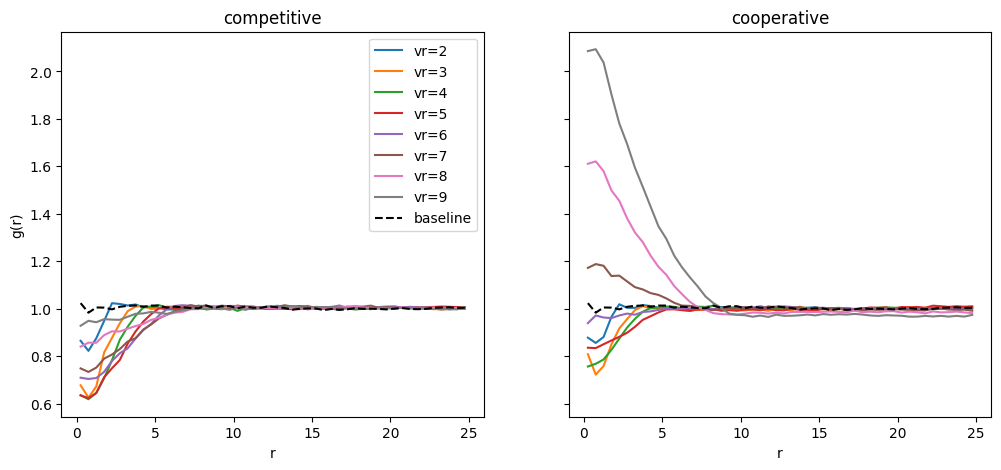

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, visual_range in enumerate(visual_ranges):
        ax[idx_sd].plot(r_c, grs[idx_sd, :, idx_vr].mean(0), label=f"vr={visual_range}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

for i in  [0,1]:
    ax[i].plot(r_c, np.array(gr_baseline).mean(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("g(r)")
plt.setp(ax, xlabel = "r")

[Text(0.5, 0, 'Visual range'), Text(0.5, 0, 'Visual range')]

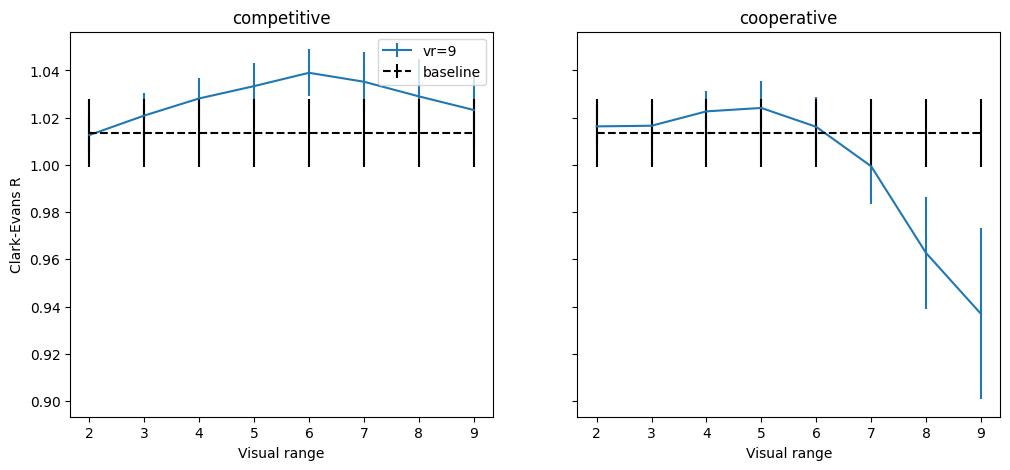

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
        
    ax[idx_sd].errorbar(visual_ranges, cr_idx[idx_sd].mean(0), yerr=cr_idx[idx_sd].std(0), label=f"vr={visual_range}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

ax[0].errorbar(visual_ranges, np.ones_like(visual_ranges) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--')
ax[1].errorbar(visual_ranges, np.ones_like(visual_ranges) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = "Visual range")

#### Episodes = 10k

[Text(0.5, 0, 'r'), Text(0.5, 0, 'r')]

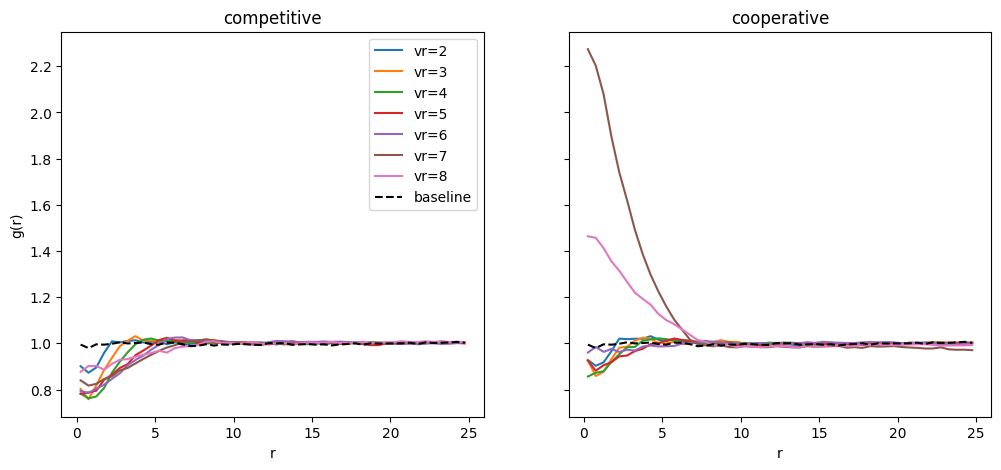

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, visual_range in enumerate(visual_ranges):
        ax[idx_sd].plot(r_c, grs[idx_sd, :, idx_vr].mean(0), label=f"vr={visual_range}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

for i in  [0,1]:
    ax[i].plot(r_c, np.array(gr_baseline).mean(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("g(r)")
plt.setp(ax, xlabel = "r")

[Text(0.5, 0, 'Visual range'), Text(0.5, 0, 'Visual range')]

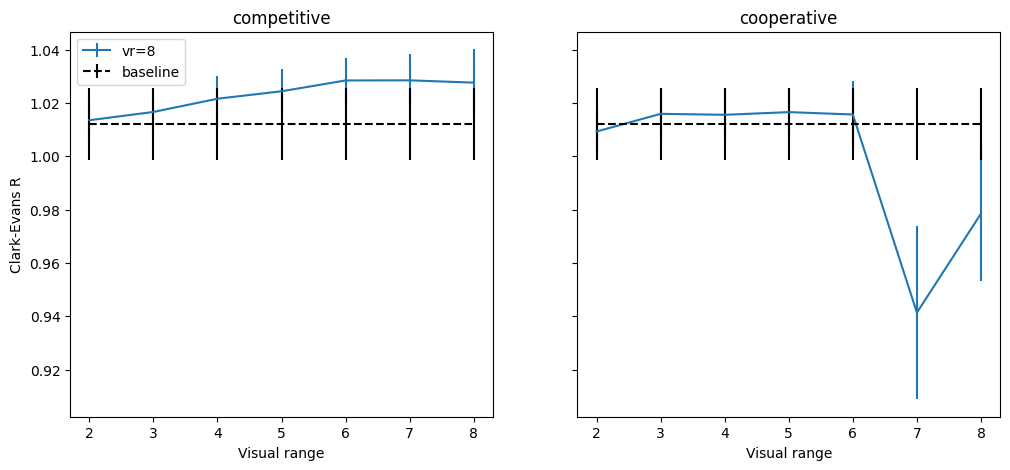

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
        
    ax[idx_sd].errorbar(visual_ranges, cr_idx[idx_sd].mean(0), yerr=cr_idx[idx_sd].std(0), label=f"vr={visual_range}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

ax[0].errorbar(visual_ranges, np.ones_like(visual_ranges) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--')
ax[1].errorbar(visual_ranges, np.ones_like(visual_ranges) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = "Visual range")

## EXP 7_1 - tau_r

In [ ]:
from rl_opts.rl_framework.numba.agents import Foragers_efficient, run_collective
from rl_opts.rl_framework.numba.environments import CollectiveEnv
import numba
import os
import numpy as np

# Change for this run:
taus_reward = np.arange(2, 11, 1)-1 # See comment in EXP_7
visual_range = 4

num_agents = 50
max_counter = 50
runs = 1

Nt = 100; L = 50; r = 0.5
agent_step = 1
tau = 2
visual_activated = True
visual_angle=np.pi / 2 # Note that this is from the center, so from +45 to -45

# State space: [counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]
state_space = np.array([max_counter, 2, 2])

time_ep = 5000
episodes = 2000

if os.getlogin() == "gorka":
    if socket.gethostname() == "gpu-qic":
        out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/"
    elif socket.gethostname() == "gpu-ada-qic":
        out_dir = "/home/gorka/rl_opts/nbs/lib_nbs/develop/results/"
elif os.getlogin() == "c7051165":
    out_dir = "/scratch/c7051165/github/rl_opts/nbs/lib_nbs/develop/results/"
out_dir = os.path.join(out_dir, f"exp_7_1")
out_dir

'/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_1'

In [ ]:
episodes = 1
time_ep = 2000

# Loading for getting runs
file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{taus_reward[0]+1}_vr_{visual_range}_ep_2000.npy"                           
h_matrix_path = os.path.join(out_dir, f"h_matrix"+file_name)
runs = np.load(h_matrix_path).shape[0]


dr = 0.5
n_bins = int(L / 2 / dr)
grs = np.zeros((2, runs, len(taus_reward), n_bins))
cr_idx = np.zeros((2, runs, len(taus_reward)))
for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, tau_reward in enumerate(tqdm(taus_reward)):

        file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward+1}_vr_{visual_range}_ep_2000.npy"
                            
        h_matrix_path = os.path.join(out_dir, 
                                    f"h_matrix"+file_name)
        try:
            mats = np.load(h_matrix_path)
        except:
            continue

        rews, posr = run_simul_collective(episodes = episodes, time_ep = time_ep, runs = runs, h_0= mats, initial_h_0=True,
                                          Nt = Nt, L = L, r = r, tau = tau, agent_step = agent_step,
                                    visual_range = visual_range, visual_angle = visual_angle, 
                                    shared_depletion = shared_depletion, tau_reward = tau_reward, upd_pos_method = 'RND', turn_angle = visual_angle)
        
        for idx_run, positions in enumerate(posr):
            r_c, gr_c, _ = compute_gr(positions[0], L=L, dr=0.5)
            grs[idx_sd, idx_run, idx_vr, :] = gr_c
            cr_idx[idx_sd, idx_run, idx_vr] = clark_evans_index(positions[0], L=L)[0]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

[Text(0.5, 0, 'r'), Text(0.5, 0, 'r')]

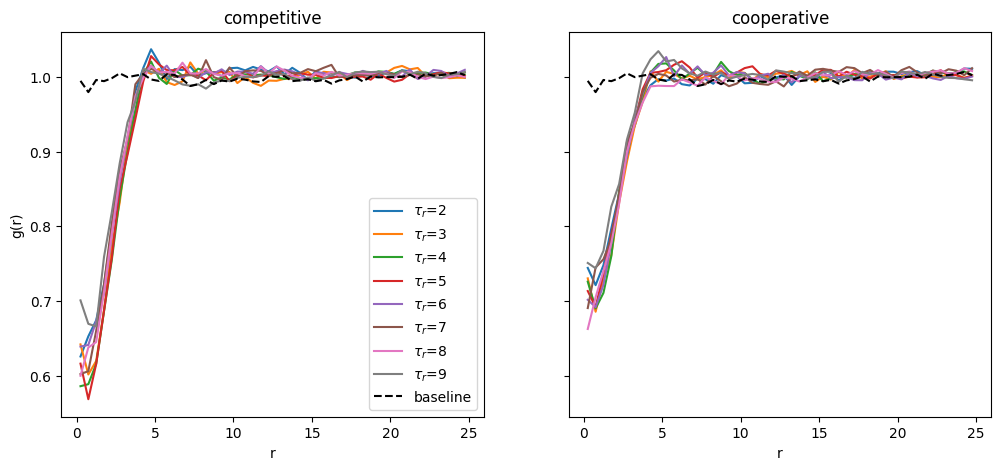

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, tau_reward in enumerate((taus_reward[:-1])):
        ax[idx_sd].plot(r_c, grs[idx_sd, :, idx_vr].mean(0), label=fr"$\tau_r$={tau_reward+1}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

for i in  [0,1]:
    ax[i].plot(r_c, np.array(gr_baseline).mean(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("g(r)")
plt.setp(ax, xlabel = "r")

[Text(0.5, 0, 'Visual range'), Text(0.5, 0, 'Visual range')]

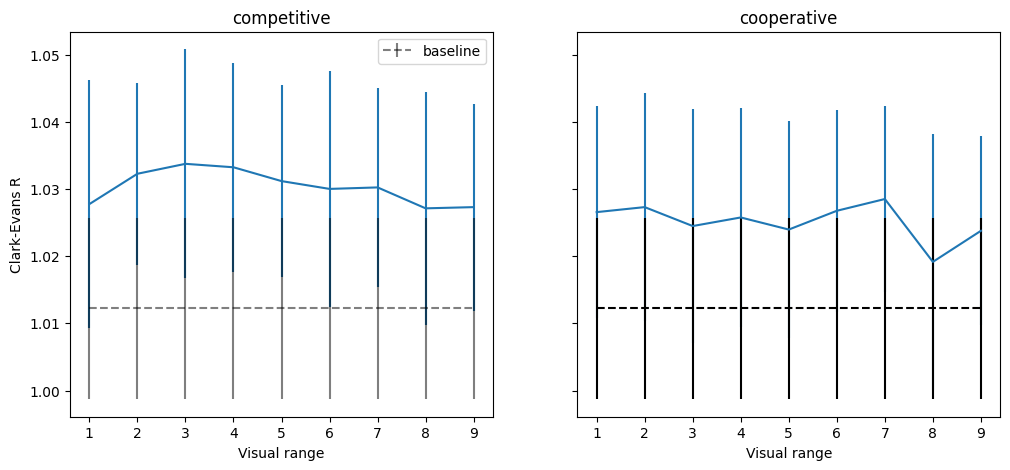

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
        
    ax[idx_sd].errorbar(taus_reward, cr_idx[idx_sd].mean(0), yerr=cr_idx[idx_sd].std(0))
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

ax[0].errorbar(taus_reward, np.ones_like(taus_reward) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--', alpha = 0.5)
ax[1].errorbar(taus_reward, np.ones_like(taus_reward) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = "Visual range")